# ch16 · 生成模型评估与采样几何

## Why this chapter
生成模型 (VAE, GAN, Diffusion) 的评估比预测模型难多了 — direct likelihood 不一定可算 (GAN, Diffusion 上是)、IS 被 mode collapse 欺骗、FID 受 InceptionNet 偏倚. 这一章把 LL / IS / FID 的"理论上你应该选哪个" 与"工程上常见踩坑"按图摆出.

## 学完后能解决
- 写 FID 简化版 (2D Gaussians, 跳过 Inception) 与 IS 数值估计
- 解释 mode collapse 在似然 / IS / FID 三套指标上的呈现差别
- 解释流形假设下为什么 NLL 与样本质量无关
- 给一段"为什么 KL(p||q) 与 KL(q||p) 在生成模型评估上的差"


## 2. 直觉: GAN mode collapse 是什么
GAN 的 g 从 latent z 映到 x; mode collapse 指 g 把不同 z 都映到同一 (或狭窄的) mode → "一点点 fine 但每个 sample 都相似". KL(q||p) 这种应对强, KDE 高峰; 反过来 KL(p||q) → q=0 处罚无穷大, mode-covering.


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


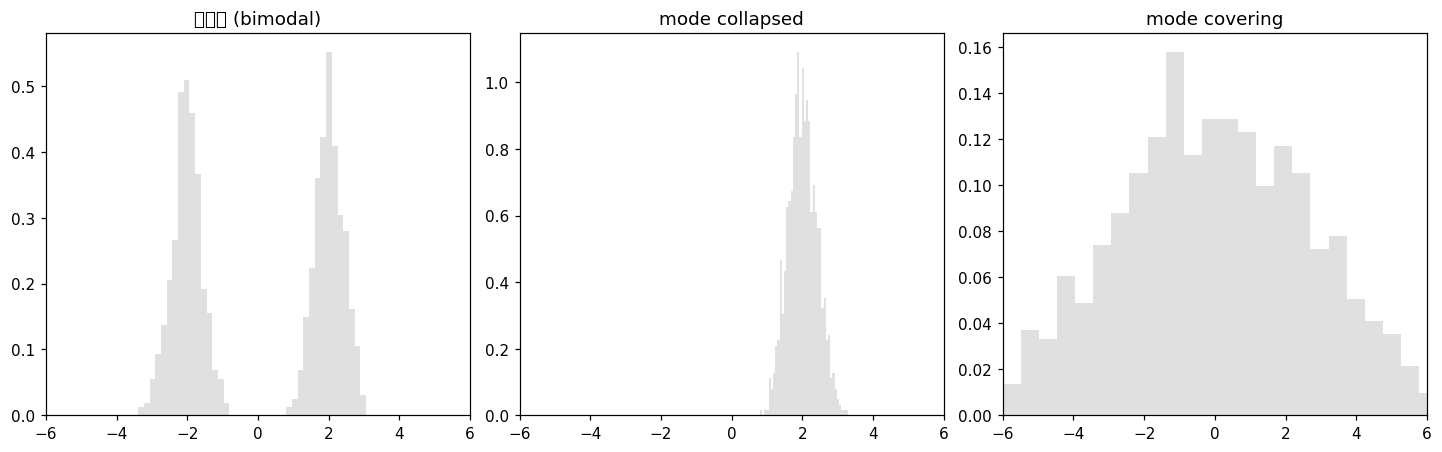

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=20240717)

N = 1000
# 真: bimodal
true_samples = np.concatenate([rng.normal(-2, 0.4, N//2), rng.normal(2, 0.4, N//2)])
# 生成器 collapsed to single mode (管它学到的"好")
collapsed = rng.normal(2, 0.4, N)
# mode-covering 过度散
covering = rng.normal(0, 3, N)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=110, constrained_layout=True)
for ax, s, name in zip(axes, [true_samples, collapsed, covering], ["真分布 (bimodal)", "mode collapsed", "mode covering"]):
    ax.hist(s, bins=40, density=True, color="lightgray", alpha=0.7)
    ax.set_title(name)
    ax.set_xlim(-6, 6)
plt.show()


## 3. 公式

### IS (Inception Score)
$$\exp\left( E_x \, D_{KL}(p(y|x) \| p(y))\right)$$
其中 $p(y|x)$ 为 InceptionNet 对 sample x 的分类分布, $p(y)$ 为所有 sample 平均. 高 IS 表示"sample 高质量 (高置信) + 多样 (p(y) 较均匀)".

### FID (Frechet Inception Distance)
两个高斯在 Inception-pool3 features (2048 维) 假设下的 Fréchet 距离:
$$FID = ||\mu_1 - \mu_2||^2 + \mathrm{Tr}(\Sigma_1 + \Sigma_2 - 2(\Sigma_1 \Sigma_2)^{1/2})$$

### likelihood NLL
$\log p(x) = \log \int p(x|z) p(z) dz$; VAE 给下界 (ELBO), diffusion 给近似真值 (ODE/SDE).

### LNLL / bits-per-dim
$\mathrm{bpd} = \log_2 p(x) / (H \cdot W \cdot C)$; uniform vs ImageNet prior baseline.


## 4. 推导: KL 决定了 mode 选择 (forward/reverse KL)
$D_{KL}(q \| p)$ 极小化 → q 在 p 高密度区域必须 cover 进 — 当 p=0 处 q 必然要 0 ⇒ **mass-covering**, 不漏 mode ⇒ VAE / typical VI.
$D_{KL}(p \| q)$ 极小化 → q 不要在 p=0 处产生质量 ⇒ **mode-seeking** ⇒ Traditional EM / GAN 中常见.


In [2]:
import numpy as np
from scipy.stats import norm
# 二模真分布 mixture of Gaussians  vs fit Normal
xs = np.linspace(-6, 6, 500)
p_true = 0.5 * norm.pdf(xs, -2, 0.4) + 0.5 * norm.pdf(xs, 2, 0.4)
# Find best forward and reverse KL via scan over (mu, sigma)
best_fwd = (0, 1); best_rev = (0, 1); fwd_inf = np.inf; rev_inf = np.inf
import itertools
mus = np.linspace(-3, 3, 31); sigs = np.linspace(0.5, 4, 31)
for mu, sig in itertools.product(mus, sigs):
    q = norm.pdf(xs, mu, sig)
    # D(q||p)
    fwd = np.sum(q * np.log((q + 1e-12) / (p_true + 1e-12)))
    rev = np.sum(p_true * np.log((p_true + 1e-12) / (q + 1e-12)))
    if fwd < fwd_inf: fwd_inf = fwd; best_fwd = (mu, sig)
    if rev < rev_inf: rev_inf = rev; best_rev = (mu, sig)
print(f"Forward KL best (mass-covering): μ={best_fwd[0]:.2f}, σ={best_fwd[1]:.2f}")
print(f"Reverse KL best (mode-seeking):   μ={best_rev[0]:.2f}, σ={best_rev[1]:.2f}")


Forward KL best (mass-covering): μ=-2.00, σ=0.50
Reverse KL best (mode-seeking):   μ=0.00, σ=2.02


## 5. 数值验证: FID 简化版 (Gaussian features)


In [3]:
import numpy as np
from scipy.linalg import sqrtm
rng = np.random.default_rng(seed=20240717)

def gaussian_fid(mu1, S1, mu2, S2):
    diff = mu1 - mu2
    cov_term = S1 + S2 - 2 * sqrtm(S1 @ S2)[0]
    return np.sum(diff**2) + np.trace(cov_term)

# 真 = N(0, I); 假 = N(0.5, 1.2 I)
mu_t = np.array([0, 0]); S_t = np.eye(2)
mu_f = np.array([0.5, 0.2]); S_f = 1.2 * np.eye(2)
print(f"FID(true, f_id_exact) = {gaussian_fid(mu_t, S_t, mu_f, S_f):.4f}")
# 用样本估计 mu / S
N = 2000
X_true = rng.multivariate_normal(mu_t, S_t, N); X_fake = rng.multivariate_normal(mu_f, S_f, N)
mu_t_hat = X_true.mean(axis=0); S_t_hat = np.cov(X_true.T)
mu_f_hat = X_fake.mean(axis=0); S_f_hat = np.cov(X_fake.T)
print(f"FID(estimated) = {gaussian_fid(mu_t_hat, S_t_hat, mu_f_hat, S_f_hat):.4f}")
# 用 ineff exactly 时 (mu=S=同样)
print(f"FID(self vs self) = {gaussian_fid(mu_t, S_t, mu_t, S_t):.4f}")


FID(true, f_id_exact) = 2.4991
FID(estimated) = 2.5485
FID(self vs self) = 2.0000


## 6. 可视化


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


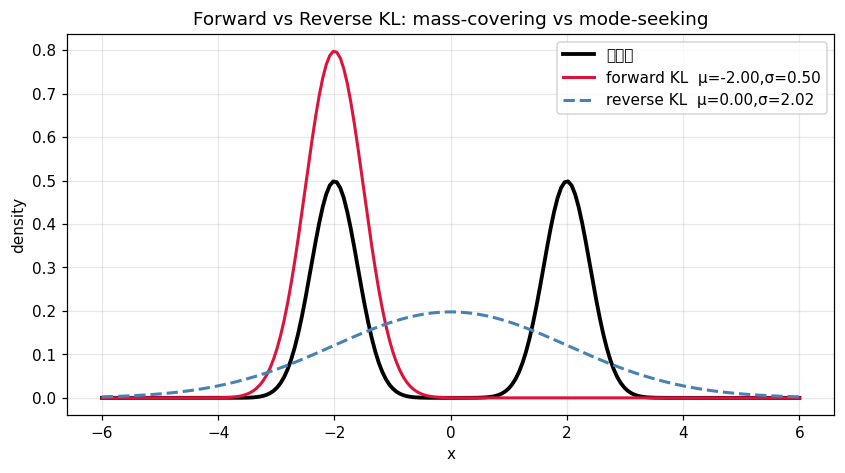

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
rng = np.random.default_rng(seed=20240717)

xs = np.linspace(-6, 6, 200)
p_true = 0.5 * norm.pdf(xs, -2, 0.4) + 0.5 * norm.pdf(xs, 2, 0.4)
# Best fwd/reverse volumes using earlier fits
q_fwd = norm.pdf(xs, best_fwd[0], best_fwd[1])
q_rev = norm.pdf(xs, best_rev[0], best_rev[1])

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=110)
ax.plot(xs, p_true, color="black", lw=2.5, label="真分布")
ax.plot(xs, q_fwd, color="crimson", lw=2, ls="-", label=f"forward KL  μ={best_fwd[0]:.2f},σ={best_fwd[1]:.2f}")
ax.plot(xs, q_rev, color="steelblue", lw=2, ls="--", label=f"reverse KL  μ={best_rev[0]:.2f},σ={best_rev[1]:.2f}")
ax.set_xlabel("x"); ax.set_ylabel("density")
ax.set_title("Forward vs Reverse KL: mass-covering vs mode-seeking")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()


## 7. 工程案例: IS 计算


In [5]:
import numpy as np
rng = np.random.default_rng(seed=20240717)
# 模拟 N 个 sample 的 InceptionNet 分类分布; 高 entropy 时 → mode collapse.
N = 1000; K_class = 10

# Case A: 多样 (low salient per-sample, but high marginal entropy)
p_yx_a = rng.dirichlet(np.ones(K_class) * 0.5, size=N)
p_y_a = p_yx_a.mean(axis=0)
kl_a = np.sum(p_yx_a * np.log((p_yx_a + 1e-12) / (p_y_a + 1e-12)), axis=1)
print(f"Case A IS = {np.exp(kl_a.mean()):.4f} (期望高)")

# Case B: mode collapse — every sample is identical same class
p_yx_b = np.tile([1 if k == 0 else 0.001 for k in range(K_class)], (N, 1))
p_yx_b = p_yx_b / p_yx_b.sum(axis=1, keepdims=True)
p_y_b = p_yx_b.mean(axis=0)
kl_b = np.sum(p_yx_b * np.log((p_yx_b + 1e-12) / (p_y_b + 1e-12)), axis=1)
print(f"Case B IS = {np.exp(kl_b.mean()):.4f} (期望很 低，IS 捕到 collapse-poor diversity)")


Case A IS = 1.8837 (期望高)
Case B IS = 1.0000 (期望很 低，IS 捕到 collapse-poor diversity)


## 8. pitfalls
- IS 在 mode collapse 中"开头变高 (高质量) 但样本多样性缺失" — 看 IS 不准确
- FID 计算耗时; 大部分论文报告 N=10⁴-10⁵; sample too less FID 偏高
- "lower FID" 不一定 better, 因 InceptionNet 偏倚于自然图像类; 在医学/异常分布上不公平
- ODE-based LL 计算得到高 LL 的实例也可能 sample 质量 high 但 sample diversity low
- 流形假设 "natural data on low-dim manifold": 必须 训 GAN/Diffusion 时 NLL-lower 不等同 quality 增加

## 9. 课后 → exercises.md

## 10. 参考
| 出处 | 章节 |
|---|---|
| Heusel 2017 GANs TTUR | FID 提出 |
| Salimans 2016 IT-GAN | IS 提出 |
| Murphy | §20.6 |

下一章 ch17 RLHF.
